# Analyse des resultats simu5G

Ce notebook lit et analyse les fichiers de resultats OMNeT++/simu5G (.sca et .vec)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Chemin vers les resultats
results_dir = Path(r"C:\Users\Utilisateur\Desktop\PFE_BigData\PFE_Bigdata\PFE-NetworkSlicing\PFE-NetworkSlicing\work\simu5g\simulation_pfe\results")
sca_file = results_dir / "Normal-0.sca"
vec_file = results_dir / "Normal-0.vec"

print(f"Fichier .sca existe : {sca_file.exists()}")
print(f"Fichier .vec existe : {vec_file.exists()}")
print(f"\nTaille .sca : {sca_file.stat().st_size / 1024:.1f} KB")
print(f"Taille .vec : {vec_file.stat().st_size / 1024 / 1024:.1f} MB")

Fichier .sca existe : True
Fichier .vec existe : True

Taille .sca : 1305.7 KB
Taille .vec : 12.8 MB


## 1. Parser le fichier .sca (scalaires)

In [2]:
def parse_sca_file(filepath):
    """Parse un fichier .sca OMNeT++ et retourne un DataFrame."""
    scalars = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('scalar'):
                parts = line.split()
                if len(parts) >= 4:
                    module = parts[1]
                    name = parts[2]
                    try:
                        value = float(parts[3]) if parts[3] not in ['nan', 'inf', '-inf'] else None
                    except:
                        value = None
                    scalars.append({
                        'module': module,
                        'name': name,
                        'value': value
                    })
    
    return pd.DataFrame(scalars)

df_sca = parse_sca_file(sca_file)
print(f"Nombre de scalaires : {len(df_sca)}")
df_sca.head(20)

Nombre de scalaires : 3722


,module,name,value
0,NetworkSlicing.upf.lo[0].lo,rcvdPkFromHl:count,0.000000e+00
1,NetworkSlicing.upf.lo[0].lo,rcvdPkFromHl:sum(packetBytes),0.000000e+00
2,NetworkSlicing.upf.lo[0].lo,passedUpPk:count,0.000000e+00
3,NetworkSlicing.upf.lo[0].lo,passedUpPk:sum(packetBytes),0.000000e+00
4,NetworkSlicing.upf.lo[0],packetDropInterfaceDown:count,0.000000e+00
5,NetworkSlicing.upf.lo[0],packetDropInterfaceDown:sum(packetBytes),0.000000e+00
6,NetworkSlicing.upf.lo[0],packetDropNoCarrier:count,0.000000e+00
7,NetworkSlicing.upf.lo[0],packetDropNoCarrier:sum(packetBytes),0.000000e+00
8,NetworkSlicing.upf.ppp[0].queue,queueLength:last,0.000000e+00
9,NetworkSlicing.upf.ppp[0].queue,queueLength:max,1.000000e+00


In [3]:
# Types de metriques disponibles
print("=== Metriques disponibles ===")
print(df_sca['name'].value_counts().head(30))

=== Metriques disponibles ===
name
sentPacketToLowerLayer:count                     75
sentPacketToLowerLayer:sum(packetBytes)          75
sentPacketToUpperLayer:count                     75
sentPacketToUpperLayer:sum(packetBytes)          75
receivedPacketFromLowerLayer:count               75
receivedPacketFromLowerLayer:sum(packetBytes)    75
receivedPacketFromUpperLayer:count               75
receivedPacketFromUpperLayer:sum(packetBytes)    75
packetDropInterfaceDown:count                    52
packetDropInterfaceDown:sum(packetBytes)         52
rlcPacketLossUl:mean                             50
rlcPacketLossDl:mean                             50
rlcCellThroughputUl:simu5g_rateavg               50
rlcCellThroughputDl:simu5g_rateavg               50
rlcPduThroughputUl:simu5g_rateavg                50
rlcPduThroughputDl:simu5g_rateavg                50
rlcPduDelayUl:mean                               50
rlcPduDelayDl:mean                               50
rlcThroughputUl:simu5g_rateav

## 2. Extraire les metriques par slice

In [4]:
def extract_slice_type(module):
    """Extrait le type de slice du nom du module."""
    module_lower = module.lower()
    if 'ueembb' in module_lower or 'serverembb' in module_lower:
        return 'eMBB'
    elif 'ueurllc' in module_lower or 'serverurllc' in module_lower:
        return 'URLLC'
    elif 'uemmtc' in module_lower or 'servermmtc' in module_lower:
        return 'mMTC'
    elif 'uebesteffort' in module_lower or 'serverbesteffort' in module_lower:
        return 'Best Effort'
    elif 'gnb' in module_lower:
        return 'gNodeB'
    else:
        return 'Other'

df_sca['slice_type'] = df_sca['module'].apply(extract_slice_type)

# Distribution par slice
print("=== Metriques par slice ===")
print(df_sca['slice_type'].value_counts())

=== Metriques par slice ===
slice_type
eMBB           1098
URLLC          1098
mMTC            586
Best Effort     586
gNodeB          182
Other           172
Name: count, dtype: int64


In [5]:
# Filtrer les metriques applicatives (UEs et serveurs)
app_metrics = df_sca[df_sca['slice_type'].isin(['eMBB', 'URLLC', 'mMTC', 'Best Effort'])]
print(f"Metriques applicatives : {len(app_metrics)}")

# Afficher par slice et metrique
pivot = app_metrics.pivot_table(index='slice_type', columns='name', values='value', aggfunc='mean')
pivot

Metriques applicatives : 3368


name,arpReplySent:count,arpReplySent:sum(packetBytes),arpRequestSent:count,arpRequestSent:sum(packetBytes),arpResolutionCompleted:count,arpResolutionFailed:count,arpResolutionInitiated:count,averageCqiDl:count,averageCqiUl:count,decapPk:count,...,rlcPacketLossUl:sum,rxPkOk:count,rxPkOk:sum(packetBytes),sentPacketToLowerLayer:count,sentPacketToLowerLayer:sum(packetBytes),sentPacketToUpperLayer:count,sentPacketToUpperLayer:sum(packetBytes),transmissionState:timeavg,txPk:count,txPk:sum(packetBytes)
slice_type,,,,,,,,,,,,,,,,,,,,,
Best Effort,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000048,3296.0,1802912.0
URLLC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000038,60302.0,14170970.0
eMBB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001146,299398.0,429636130.0
mMTC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000002,614.0,82890.0


## 3. Statistiques cles par slice

In [6]:
# Chercher les metriques de paquets recus
rcvd_metrics = app_metrics[app_metrics['name'].str.contains('rcvdPk', case=False, na=False)]
print("=== Paquets recus par slice ===")
print(rcvd_metrics.groupby('slice_type')['value'].sum())

# Chercher les metriques de paquets envoyes
sent_metrics = app_metrics[app_metrics['name'].str.contains('sentPk', case=False, na=False)]
print("\n=== Paquets envoyes par slice ===")
print(sent_metrics.groupby('slice_type')['value'].sum())

=== Paquets recus par slice ===
slice_type
Best Effort      1783136.0
URLLC           13809158.0
eMBB           427839742.0
mMTC               79206.0
Name: value, dtype: float64

=== Paquets envoyes par slice ===
Series([], Name: value, dtype: float64)


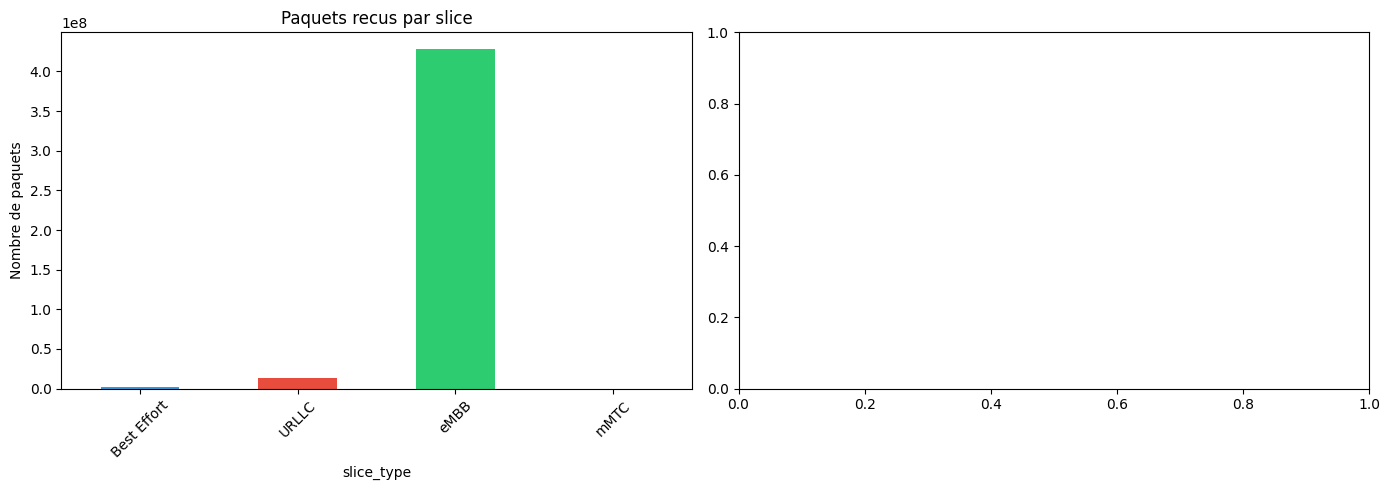

In [7]:
# Visualisation des metriques par slice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Paquets recus
if len(rcvd_metrics) > 0:
    rcvd_by_slice = rcvd_metrics.groupby('slice_type')['value'].sum()
    rcvd_by_slice.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
    axes[0].set_title('Paquets recus par slice')
    axes[0].set_ylabel('Nombre de paquets')
    axes[0].tick_params(axis='x', rotation=45)

# Paquets envoyes
if len(sent_metrics) > 0:
    sent_by_slice = sent_metrics.groupby('slice_type')['value'].sum()
    sent_by_slice.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
    axes[1].set_title('Paquets envoyes par slice')
    axes[1].set_ylabel('Nombre de paquets')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Parser le fichier .vec (vecteurs temporels)

In [8]:
def parse_vec_file(filepath, max_vectors=50):
    """Parse un fichier .vec OMNeT++ (version simplifiee)."""
    vectors = {}
    vector_attrs = {}
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            
            # Definition de vecteur : vector <id> <module> <name> [<type>]
            if line.startswith('vector '):
                parts = line.split()
                if len(parts) >= 4:
                    vec_id = parts[1]
                    module = parts[2]
                    name = parts[3]
                    if len(vector_attrs) < max_vectors:
                        vector_attrs[vec_id] = {'module': module, 'name': name}
                        vectors[vec_id] = []
            
            # Donnee : <vec_id> <event_num> <time> <value>
            elif line and line[0].isdigit() and '\t' in line:
                parts = line.split('\t')
                if len(parts) >= 4:
                    vec_id = parts[0]
                    if vec_id in vectors:
                        try:
                            time = float(parts[2])
                            value = float(parts[3])
                            vectors[vec_id].append({'time': time, 'value': value})
                        except (ValueError, IndexError):
                            pass
    
    return vectors, vector_attrs

print("Parsing du fichier .vec...")
vectors, vector_attrs = parse_vec_file(vec_file)
print(f"Vecteurs parses : {len(vectors)}")

# Lister les vecteurs
print("\n=== Vecteurs disponibles ===")
for vid, attrs in vector_attrs.items():
    n_points = len(vectors.get(vid, []))
    print(f"  [{vid}] {attrs['module']} - {attrs['name']} ({n_points} points)")

Parsing du fichier .vec...
Vecteurs parses : 50

=== Vecteurs disponibles ===
  [0] NetworkSlicing.upf.lo[0].lo - rcvdPkFromHl:vector(packetBytes) (0 points)
  [1] NetworkSlicing.upf.lo[0].lo - passedUpPk:vector(packetBytes) (0 points)
  [2] NetworkSlicing.upf.lo[0] - packetDropInterfaceDown:vector(packetBytes) (0 points)
  [3] NetworkSlicing.upf.lo[0] - packetDropNoCarrier:vector(packetBytes) (0 points)
  [4] NetworkSlicing.upf.ppp[0].queue - queueLength:vector (0 points)
  [5] NetworkSlicing.upf.ppp[0].queue - queueBitLength:vector (0 points)
  [6] NetworkSlicing.upf.ppp[0].queue - queueingTime:vector (0 points)
  [7] NetworkSlicing.upf.ppp[0].queue - incomingPacketLengths:vector (0 points)
  [8] NetworkSlicing.upf.ppp[0].queue - incomingDataRate:vector (0 points)
  [9] NetworkSlicing.upf.ppp[0].queue - outgoingPacketLengths:vector (0 points)
  [10] NetworkSlicing.upf.ppp[0].queue - outgoingDataRate:vector (0 points)
  [11] NetworkSlicing.upf.ppp[0].queue - droppedPacketLengthsQueueO

In [9]:
# Convertir un vecteur en DataFrame
def vector_to_df(vectors, vector_attrs, vec_id):
    """Convertit un vecteur en DataFrame."""
    if vec_id not in vectors:
        return None
    data = vectors[vec_id]
    if len(data) == 0:
        return None
    df = pd.DataFrame(data)
    df['module'] = vector_attrs[vec_id]['module']
    df['metric'] = vector_attrs[vec_id]['name']
    return df

# Trouver et afficher un vecteur avec des donnees
for vid, attrs in vector_attrs.items():
    if len(vectors[vid]) > 100:
        df_vec = vector_to_df(vectors, vector_attrs, vid)
        print(f"Exemple : {attrs['module']} - {attrs['name']}")
        print(df_vec.head(10))
        break

## 5. Visualisation des series temporelles

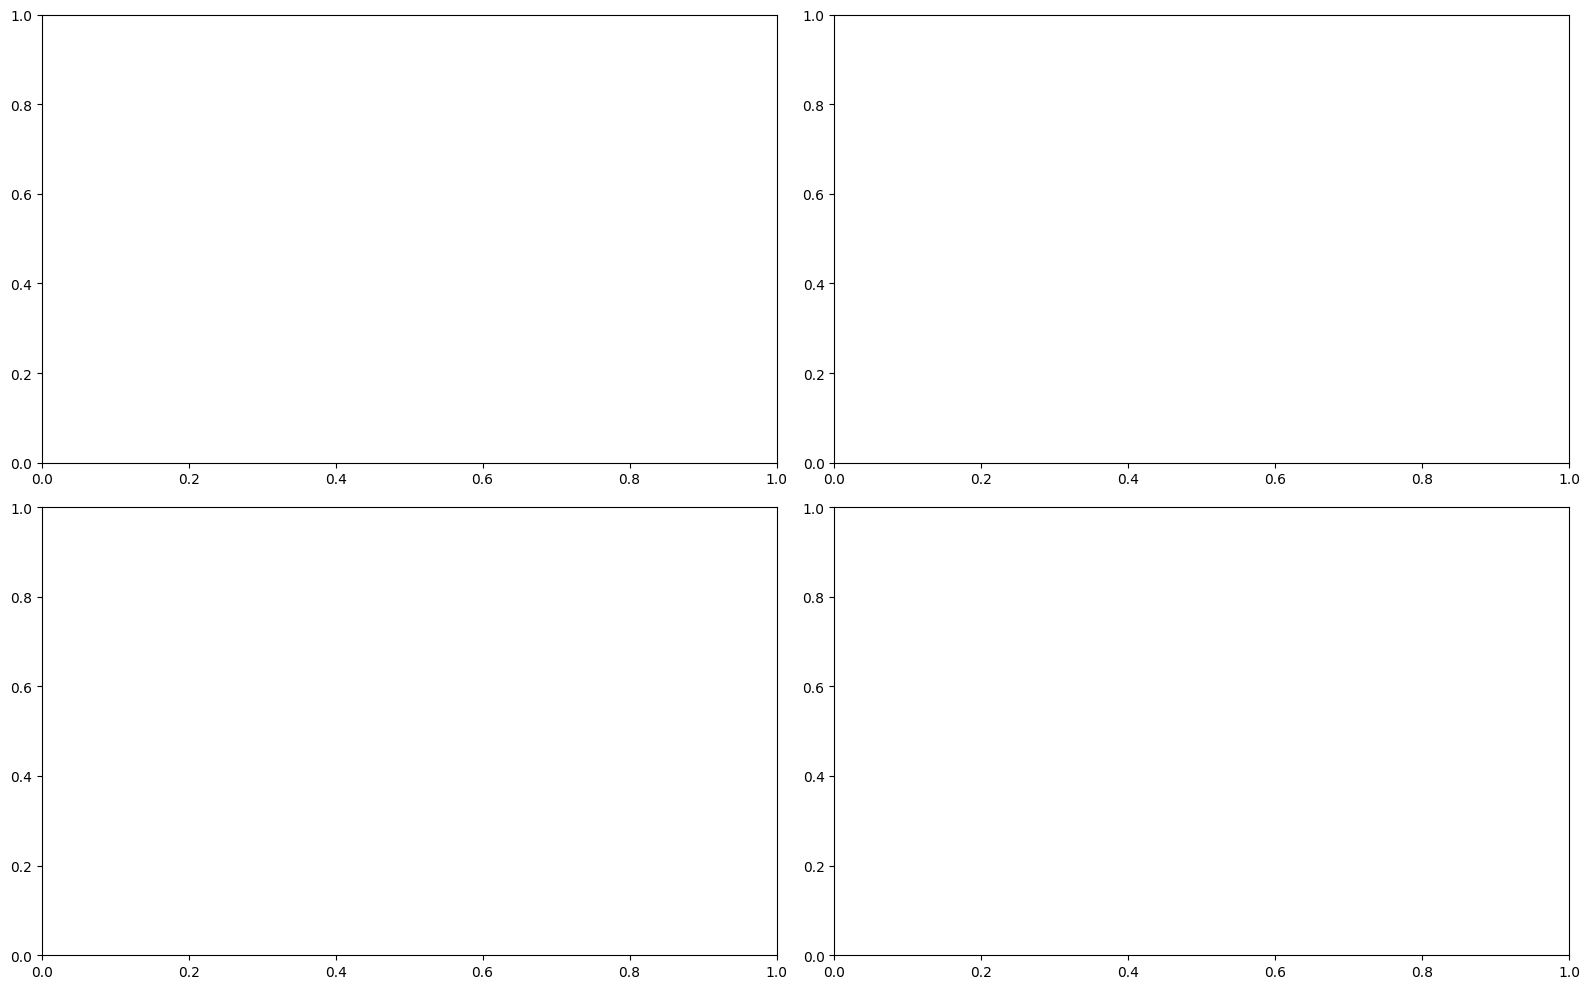

In [10]:
# Trouver les vecteurs interessants et les tracer
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
plot_idx = 0

for vid, attrs in vector_attrs.items():
    data = vectors[vid]
    if len(data) > 100 and plot_idx < 4:
        times = [d['time'] for d in data[:2000]]  # Limiter pour la visu
        values = [d['value'] for d in data[:2000]]
        
        ax = axes[plot_idx]
        ax.plot(times, values, alpha=0.7, linewidth=0.5)
        ax.set_title(f"{attrs['name']}\n{attrs['module']}", fontsize=9)
        ax.set_xlabel('Time (s)')
        ax.grid(True, alpha=0.3)
        plot_idx += 1

plt.tight_layout()
plt.savefig(results_dir.parent / 'simu5g_vectors.png', dpi=150)
plt.show()

## 6. Resume des resultats

In [11]:
print("="*60)
print("RESUME - SIMULATION simu5G")
print("="*60)
print(f"Fichier : {sca_file.name}")
print(f"Scalaires : {len(df_sca)}")
print(f"Vecteurs : {len(vectors)}")
print(f"\n--- Metriques par slice ---")
for slice_type in ['eMBB', 'URLLC', 'mMTC', 'Best Effort']:
    count = len(df_sca[df_sca['slice_type'] == slice_type])
    print(f"  {slice_type:15s} : {count} metriques")
print("="*60)

RESUME - SIMULATION simu5G
Fichier : Normal-0.sca
Scalaires : 3722
Vecteurs : 50

--- Metriques par slice ---
  eMBB            : 1098 metriques
  URLLC           : 1098 metriques
  mMTC            : 586 metriques
  Best Effort     : 586 metriques
